### Описание системы
Рассматривается колл-центр, в который поступают звонки клиентов.  
Если в момент поступления звонка есть свободный оператор, звонок сразу принимается в обслуживание.  
Если все операторы заняты, звонок помещается в очередь ожидания.  
Очередь не ограничена по длине.  
После завершения разговора оператор освобождается и принимает следующий звонок из очереди.

Система относится к классу M/M/n/∞, где:

- поток входящих звонков является пуассоновским с интенсивностью $\lambda$;
- время обслуживания одного звонка имеет экспоненциальное распределение с параметром $\mu$;
- число операторов равно $n$;
- длина очереди не ограничена;
- дисциплина обслуживания - FIFO.

### Параметры модели

- $\lambda$ - интенсивность поступления звонков;
- $\mu$ - интенсивность обслуживания одним оператором;
- $n$ - количество операторов;
- $T$ - длительность моделирования;
- $N_{\text{runs}}$ - число независимых запусков модели.

### Основные формулы

#### Коэффициент загрузки системы
$$
\rho = \frac{\lambda}{n\mu}
$$

Параметр $\rho$ показывает степень загрузки операторов.  
Для устойчивой работы системы необходимо выполнение условия:
$$
\rho < 1
$$

#### Среднее время ожидания звонка в очереди
$$
W_q = \frac{L_q}{\lambda}
$$

где $L_q$ — среднее число звонков в очереди.

#### Среднее время пребывания звонка в системе
$$
W = W_q + \frac{1}{\mu}
$$

#### Среднее число звонков в системе
$$
L = \lambda W
$$

#### Вероятность ожидания звонка
$$
P_{\text{wait}} = \frac{N_{\text{wait}}}{N_{\text{all}}}
$$

где:
- $N_{\text{wait}}$ — количество звонков, которые попали в очередь;
- $N_{\text{all}}$ — общее количество поступивших звонков.

#### Вероятность простоя системы
$$
P_0 = \frac{T_0}{T}
$$

где:
- $T_0$ — суммарное время, когда все операторы были свободны;
- $T$ — общее время моделирования.

#### Средняя длина очереди
$$
L_q = \frac{1}{T}\int_0^T q(t)\,dt
$$

где $q(t)$ — количество звонков в очереди в момент времени $t$.

### Алгоритм работы модели

1. Задаются параметры системы: интенсивность поступления звонков $\lambda$, интенсивность обслуживания $\mu$, число операторов $n$, время моделирования $T$ и число запусков $N_{\text{runs}}$.
2. Для каждого запуска формируется поток входящих звонков с экспоненциальными интервалами между поступлениями.
3. Для каждого звонка определяется момент поступления в систему.
4. Если в момент поступления есть свободный оператор, звонок сразу поступает на обслуживание.
5. Если все операторы заняты, звонок помещается в очередь и ожидает освобождения ближайшего оператора.
6. Для каждого звонка фиксируются:
   - время поступления;
   - время начала обслуживания;
   - время завершения обслуживания;
   - время ожидания в очереди;
   - факт ожидания.
7. В ходе моделирования вычисляются:
   - вероятность простоя системы;
   - вероятность ожидания звонка;
   - средняя длина очереди;
   - среднее время ожидания;
   - среднее время пребывания звонка в системе;
   - коэффициент загрузки системы.
8. Моделирование повторяется многократно.
9. Итоговые характеристики определяются усреднением результатов по всем запускам.
10. Далее анализируется влияние числа операторов $n$ и интенсивности обслуживания $\mu$ на эффективность работы колл-центра.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque

In [2]:
lambda_calls = 10
mu_service = 3
n_operators = 4
simulation_time = 1000
n_runs = 200

In [3]:
def simulate_call_center(lambda_calls, mu_service, n_operators, simulation_time, random_state=None):
    rng = np.random.default_rng(random_state)
    
    arrival_times = []
    t = 0.0
    while True:
        t += rng.exponential(1 / lambda_calls)
        if t > simulation_time:
            break
        arrival_times.append(t)
    
    operator_free_times = np.zeros(n_operators)
    
    waiting_times = []
    system_times = []
    waited_flags = []
    
    events = []
    
    for arrival_time in arrival_times:
        operator_index = np.argmin(operator_free_times)
        service_start = max(arrival_time, operator_free_times[operator_index])
        service_time = rng.exponential(1 / mu_service)
        service_end = service_start + service_time
        wait_time = service_start - arrival_time
        system_time = service_end - arrival_time
        
        operator_free_times[operator_index] = service_end
        
        waiting_times.append(wait_time)
        system_times.append(system_time)
        waited_flags.append(wait_time > 0)
        
        events.append((arrival_time, 1))
        events.append((service_start, 2))
        events.append((service_end, 3))
    
    events.sort(key=lambda x: (x[0], x[1]))
    
    queue_length = 0
    busy_operators = 0
    last_time = 0.0
    queue_area = 0.0
    idle_all_time = 0.0
    busy_area = 0.0
    
    for time, event_type in events:
        dt = time - last_time
        queue_area += queue_length * dt
        busy_area += busy_operators * dt
        
        if busy_operators == 0:
            idle_all_time += dt
        
        if event_type == 1:
            if busy_operators >= n_operators:
                queue_length += 1
        elif event_type == 2:
            if queue_length > 0:
                queue_length -= 1
            busy_operators += 1
        elif event_type == 3:
            busy_operators -= 1
        
        last_time = time
    
    if last_time < simulation_time:
        dt = simulation_time - last_time
        queue_area += queue_length * dt
        busy_area += busy_operators * dt
        if busy_operators == 0:
            idle_all_time += dt
    
    total_calls = len(arrival_times)
    P_wait = np.mean(waited_flags)
    P0 = idle_all_time / simulation_time
    Lq = queue_area / simulation_time
    Wq = np.mean(waiting_times)
    W = np.mean(system_times)
    rho_emp = busy_area / (simulation_time * n_operators)
    
    return {
        "total_calls": total_calls,
        "P_wait": P_wait,
        "P0": P0,
        "Lq": Lq,
        "Wq": Wq,
        "W": W,
        "rho_emp": rho_emp
    }

In [4]:
def run_multiple_simulations(lambda_calls, mu_service, n_operators, simulation_time, n_runs):
    results = []
    
    for run in range(n_runs):
        result = simulate_call_center(
            lambda_calls=lambda_calls,
            mu_service=mu_service,
            n_operators=n_operators,
            simulation_time=simulation_time,
            random_state=run
        )
        results.append(result)
    
    df = pd.DataFrame(results)
    
    summary = pd.DataFrame({
        "Показатель": ["Общее число звонков", "Вероятность ожидания", "Вероятность простоя", "Средняя длина очереди", "Среднее время ожидания", "Среднее время в системе", "Коэффициент загрузки"],
        "Среднее значение": [
            df["total_calls"].mean(),
            df["P_wait"].mean(),
            df["P0"].mean(),
            df["Lq"].mean(),
            df["Wq"].mean(),
            df["W"].mean(),
            df["rho_emp"].mean()
        ]
    })
    
    return df, summary

In [5]:
runs_df, summary_df = run_multiple_simulations(
    lambda_calls=lambda_calls,
    mu_service=mu_service,
    n_operators=n_operators,
    simulation_time=simulation_time,
    n_runs=n_runs
)

summary_df

,Показатель,Среднее значение
0,Общее число звонков,9989.630000
1,Вероятность ожидания,0.652659
2,Вероятность простоя,0.021907
3,Средняя длина очереди,3.214782
4,Среднее время ожидания,0.321534
5,Среднее время в системе,0.654307
6,Коэффициент загрузки,0.831071


In [6]:
runs_df.describe()

,total_calls,P_wait,P0,Lq,Wq,W,rho_emp
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,9989.630000,0.652659,0.021907,3.214782,0.321534,0.654307,0.831071
std,104.617528,0.023976,0.002823,0.579941,0.056025,0.057727,0.011871
min,9742.000000,0.601771,0.013787,2.217580,0.223119,0.546317,0.803067
25%,9921.000000,0.636852,0.019827,2.874674,0.288806,0.620211,0.823748
50%,9986.000000,0.649706,0.021985,3.144251,0.314303,0.644951,0.829769
75%,10055.000000,0.666733,0.023619,3.452977,0.345329,0.681101,0.837459
max,10278.000000,0.723879,0.030527,6.167055,0.601078,0.937537,0.864584


In [7]:
operators_range = range(1, 11)
operators_results = []

for n_val in operators_range:
    _, summary = run_multiple_simulations(
        lambda_calls=lambda_calls,
        mu_service=mu_service,
        n_operators=n_val,
        simulation_time=simulation_time,
        n_runs=n_runs
    )
    
    values = dict(zip(summary["Показатель"], summary["Среднее значение"]))
    operators_results.append({
        "n": n_val,
        "P_wait": values["Вероятность ожидания"],
        "P0": values["Вероятность простоя"],
        "Lq": values["Средняя длина очереди"],
        "Wq": values["Среднее время ожидания"],
        "W": values["Среднее время в системе"],
        "rho": values["Коэффициент загрузки"]
    })

df_operators = pd.DataFrame(operators_results)
df_operators

,n,P_wait,P0,Lq,Wq,W,rho
0,1,0.999852,0.000157,11608.024248,1161.814286,1162.147059,3.324284
1,2,0.999584,0.000192,3304.751976,330.720874,331.053647,1.662142
2,3,0.998034,0.000326,544.259756,54.418208,54.750981,1.108095
3,4,0.652659,0.021907,3.214782,0.321534,0.654307,0.831071
4,5,0.323437,0.032225,0.641261,0.064155,0.396927,0.664857
5,6,0.146081,0.034971,0.182396,0.018248,0.351020,0.554047
6,7,0.060297,0.035732,0.055314,0.005533,0.338306,0.474898
7,8,0.022667,0.035951,0.016417,0.001642,0.334414,0.415535
8,9,0.007754,0.036014,0.004652,0.000465,0.333238,0.369365
9,10,0.002401,0.036028,0.001248,0.000125,0.332897,0.332428


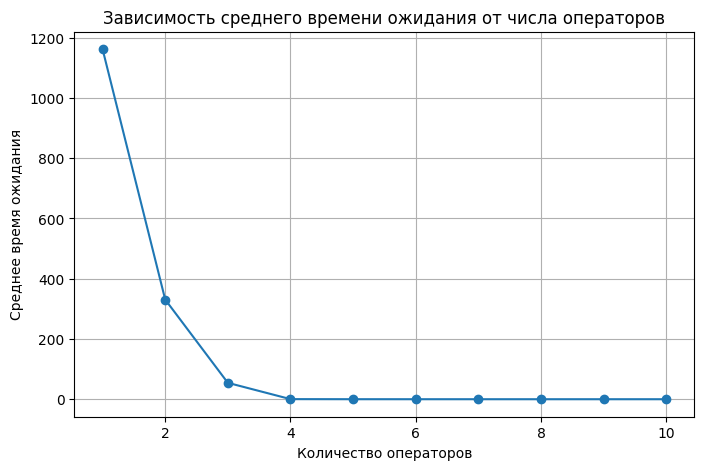

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(df_operators["n"], df_operators["Wq"], marker="o")
plt.xlabel("Количество операторов")
plt.ylabel("Среднее время ожидания")
plt.title("Зависимость среднего времени ожидания от числа операторов")
plt.grid(True)
plt.show()

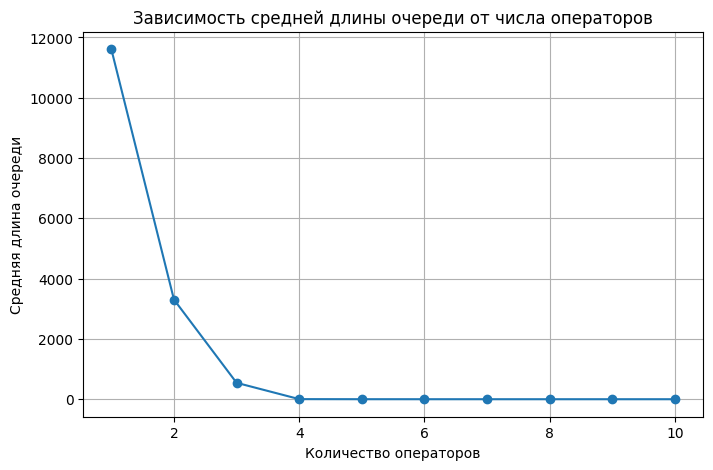

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(df_operators["n"], df_operators["Lq"], marker="o")
plt.xlabel("Количество операторов")
plt.ylabel("Средняя длина очереди")
plt.title("Зависимость средней длины очереди от числа операторов")
plt.grid(True)
plt.show()

## Анализ влияния числа операторов

При увеличении количества операторов уменьшается нагрузка на каждого из них, снижается вероятность того, что поступивший звонок попадет в очередь, уменьшается среднее время ожидания, а также сокращается средняя длина очереди.  
Это соответствует логике работы колл-центра: чем больше операторов одновременно принимают звонки, тем выше пропускная способность системы.

In [10]:
mu_range = np.arange(1.5, 6.5, 0.5)
mu_results = []

for mu_val in mu_range:
    _, summary = run_multiple_simulations(
        lambda_calls=lambda_calls,
        mu_service=mu_val,
        n_operators=n_operators,
        simulation_time=simulation_time,
        n_runs=n_runs
    )
    
    values = dict(zip(summary["Показатель"], summary["Среднее значение"]))
    mu_results.append({
        "mu": mu_val,
        "P_wait": values["Вероятность ожидания"],
        "P0": values["Вероятность простоя"],
        "Lq": values["Средняя длина очереди"],
        "Wq": values["Среднее время ожидания"],
        "W": values["Среднее время в системе"],
        "rho": values["Коэффициент загрузки"]
    })

df_mu = pd.DataFrame(mu_results)
df_mu

,mu,P_wait,P0,Lq,Wq,W,rho
0,1.5,0.999279,0.000138,3302.556804,330.501087,331.166632,1.662142
1,2.0,0.998768,0.000166,1230.407360,123.095074,123.594232,1.246606
2,2.5,0.971065,0.001364,65.356683,6.515431,6.914758,0.997285
3,3.0,0.652659,0.021907,3.214782,0.321534,0.654307,0.831071
4,3.5,0.447233,0.047134,1.106675,0.110719,0.395953,0.712346
5,4.0,0.316707,0.074412,0.524545,0.052482,0.302062,0.623303
6,4.5,0.230731,0.102736,0.287496,0.028766,0.250614,0.554047
7,5.0,0.172134,0.131310,0.171942,0.017204,0.216868,0.498643
8,5.5,0.130872,0.159483,0.109240,0.010930,0.192443,0.453311
9,6.0,0.101329,0.186936,0.072627,0.007267,0.173653,0.415535


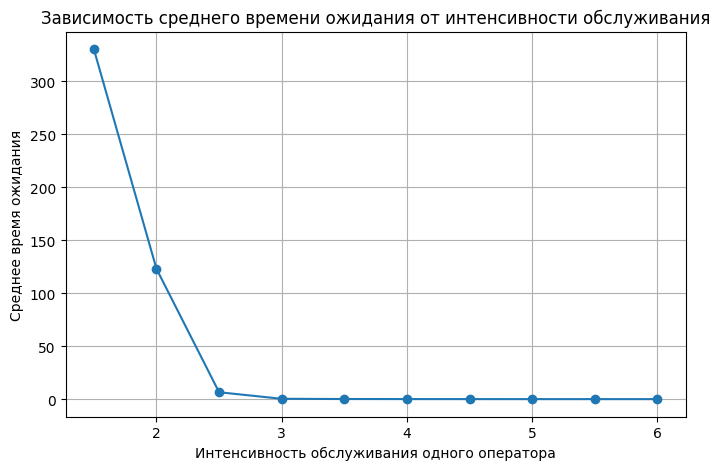

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(df_mu["mu"], df_mu["Wq"], marker="o")
plt.xlabel("Интенсивность обслуживания одного оператора")
plt.ylabel("Среднее время ожидания")
plt.title("Зависимость среднего времени ожидания от интенсивности обслуживания")
plt.grid(True)
plt.show()

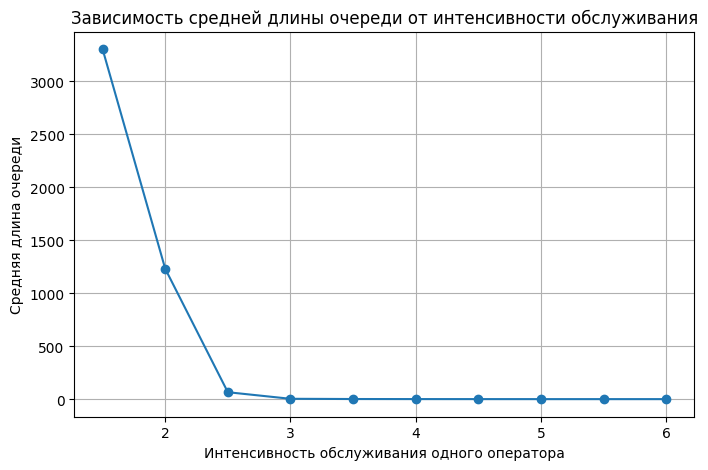

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(df_mu["mu"], df_mu["Lq"], marker="o")
plt.xlabel("Интенсивность обслуживания одного оператора")
plt.ylabel("Средняя длина очереди")
plt.title("Зависимость средней длины очереди от интенсивности обслуживания")
plt.grid(True)
plt.show()

## Анализ влияния интенсивности обслуживания

При увеличении интенсивности обслуживания один оператор обрабатывает звонки быстрее.  
Это приводит к уменьшению времени ожидания клиентов в очереди, сокращению средней длины очереди и снижению нагрузки на систему в целом.  
Для колл-центра это означает, что повышение скорости обработки звонков положительно влияет на качество обслуживания клиентов.

## Выводы

В данной работе был смоделирован колл-центр как многоканальная система массового обслуживания с ожиданием типа M/M/n/∞.  
Входящий поток представлялся потоком звонков клиентов, а обслуживание выполнялось операторами.

В результате моделирования были определены следующие характеристики системы:

- вероятность простоя системы;
- вероятность ожидания звонка в очереди;
- средняя длина очереди;
- среднее время ожидания звонка;
- среднее время пребывания звонка в системе;
- коэффициент загрузки операторов.

По результатам анализа установлено:

1. При увеличении числа операторов уменьшаются среднее время ожидания звонков и средняя длина очереди.
2. При увеличении интенсивности обслуживания снижается нагрузка на систему и повышается эффективность работы колл-центра.
3. При высокой загрузке операторов резко возрастают длина очереди и время ожидания клиентов.
4. Для устойчивой и эффективной работы колл-центра необходимо выбирать такие параметры системы, при которых нагрузка на операторов не приближается к критической.